In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

from specula.mmlib.utils import get_pupil_mask, read_freq, get_psd

import os
root_dir = '/raid1/mmenessini/calibration/SOUL'
main_config = 'soul_main.yml'

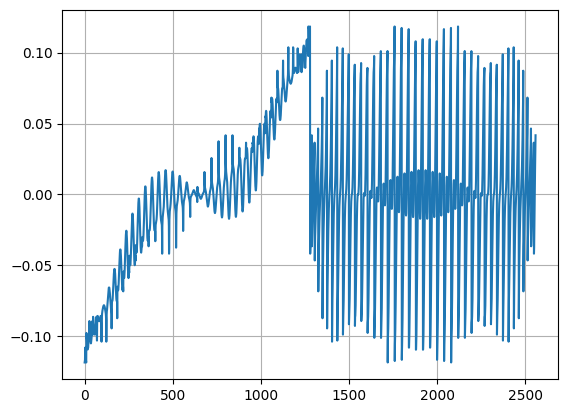

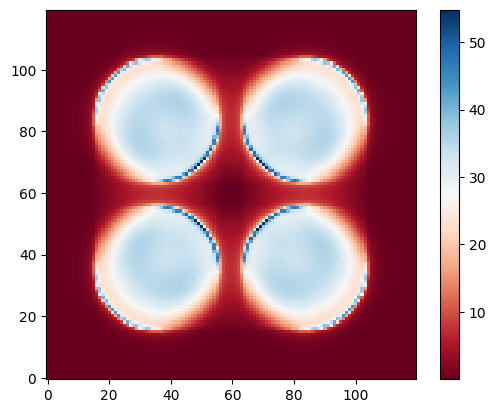

In [10]:
pyr_mask = get_pupil_mask(npix=120,filepath=os.path.join(root_dir,'pupils/pyr_pupdata_40x40.fits'))

frame = fits.getdata(os.path.join(root_dir, 'frames/pyr2.0_40x40_frame_null.fits'))[0]

sn = fits.getdata(os.path.join(root_dir, 'slopenulls/pyr2.0_40x40_sn.fits'))

thrp = np.sum(frame[pyr_mask])/np.sum(frame)

# sn /= np.sum(abs(sn))
# sn_ri /= np.sum(abs(sn_ri))/thrp
n_subaps = np.sum(pyr_mask)/4

plt.figure()
plt.plot(sn)
plt.grid()

plt.figure()
plt.imshow(frame,cmap='RdBu',origin='lower')
plt.colorbar()

In [22]:
aliaspath = os.path.join(root_dir,'aliasing')
os.makedirs(aliaspath,exist_ok=True)
fs = read_freq(params_path=f'./{main_config}')

alias_modes = fits.getdata(os.path.join(root_dir,'scratch_aliasing','pyr_modes.fits'))
psd,f = get_psd(alias_modes.T, nperseg=1024, dt=1/fs)
tag = f'pyr_modes_alias_PSD'
fits.writeto(os.path.join(aliaspath,tag+'.fits'),psd,overwrite=True)
print('Saved aliasing PSD as: '+tag)

atmo_modes = fits.getdata(os.path.join(root_dir,'scratch_aliasing','atmo_res.fits'))
atmo_psd,atmo_f = get_psd(atmo_modes.T, nperseg=1024, dt=1/fs)

print(psd.shape,f.shape)

Saved aliasing PSD as: pyr_modes_alias_PSD
(660, 513) (513,)


(np.float64(1.6608205782312926), np.float64(850.3401360544218))

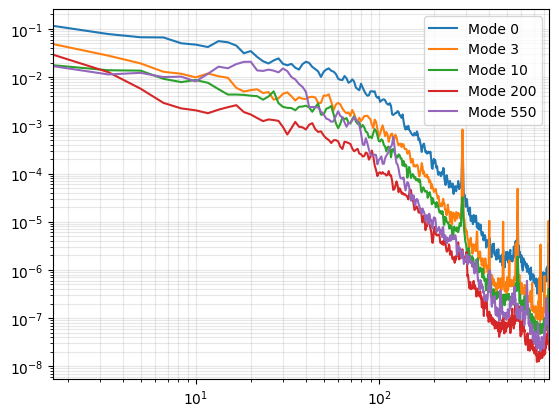

In [ ]:
plt.figure()
for mode in np.array([0,3,10,200,550]):
    plt.loglog(f,psd[mode],label=f'Mode {mode}')
plt.legend()
plt.grid(which='both',alpha=0.3)
plt.xlim([f[1],f[-1]])

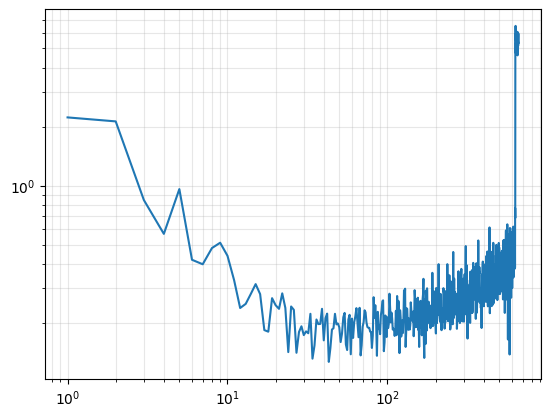

In [25]:
from scipy.integrate import simpson

alias = simpson(psd,f)

x = np.arange(len(alias))+1

plt.figure()
plt.loglog(x,alias)
plt.grid(which='both',alpha=0.3)

(np.float64(1.6608205782312926), np.float64(850.3401360544218))

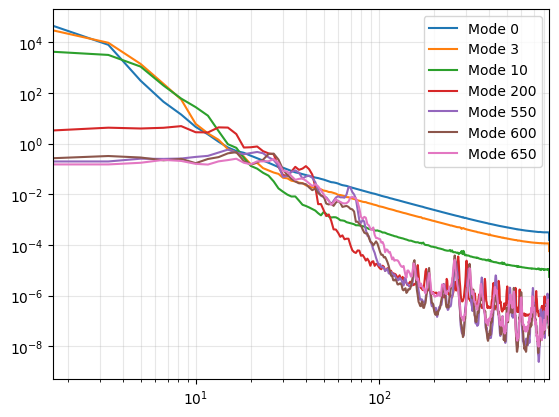

In [24]:
plt.figure()
for mode in np.array([0,3,10,200,550,600,650]):
    plt.loglog(atmo_f,atmo_psd[mode],label=f'Mode {mode}')
plt.legend()
plt.grid(which='both',alpha=0.3)
plt.xlim([f[1],f[-1]])

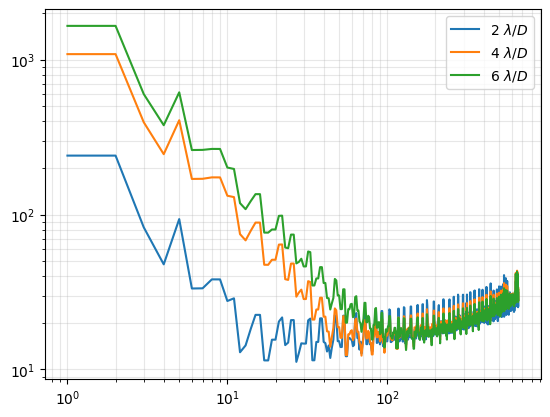

In [20]:
rec2_10x10 = fits.getdata(os.path.join(root_dir, 'rec', 'pyr2.0_10x10_54modes_rec.fits'))
rec2_20x20 = fits.getdata(os.path.join(root_dir, 'rec', 'pyr2.0_20x20_450modes_rec.fits'))
rec2 = fits.getdata(os.path.join(root_dir, 'rec', 'pyr2.0_40x40_660modes_rec.fits'))
rec4 = fits.getdata(os.path.join(root_dir, 'rec', 'pyr4.0_40x40_660modes_rec.fits'))
rec6 = fits.getdata(os.path.join(root_dir, 'rec', 'pyr6.0_40x40_660modes_rec.fits'))

x = np.arange(rec2.shape[0])+1
x10 = np.arange(rec2_10x10.shape[0])+1
x20 = np.arange(rec2_20x20.shape[0])+1

plt.figure()
# plt.loglog(x10,np.diag(rec2_10x10 @ rec2_10x10.T),label=r'2 $\lambda/D$ (10x10)')
# plt.loglog(x20,np.diag(rec2_20x20@ rec2_20x20.T),label=r'2 $\lambda/D$ (20x20)')
plt.loglog(x,np.diag(rec2 @ rec2.T),label=r'2 $\lambda/D$')
plt.loglog(x,np.diag(rec4 @ rec4.T),label=r'4 $\lambda/D$')
plt.loglog(x,np.diag(rec4 @ rec6.T),label=r'6 $\lambda/D$')
plt.legend()
plt.grid(which='both',alpha=0.3)

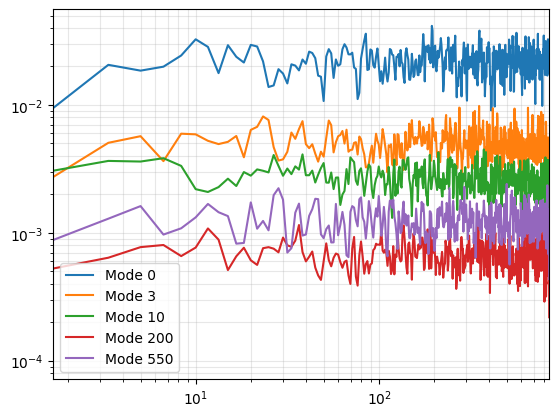

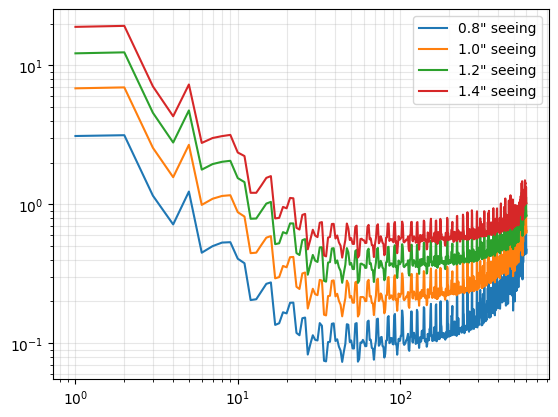

In [ ]:


hdu = fits.open(os.path.join(root_dir, 'alias/pyr3.0_s1.2_600modes_alias.fits'))
pow12 = hdu[2].data
hdu = fits.open(os.path.join(root_dir, 'alias/pyr3.0_s1.0_600modes_alias.fits'))
pow10 = hdu[2].data
hdu = fits.open(os.path.join(root_dir, 'alias/pyr3.0_s0.8_600modes_alias.fits'))
pow08 = hdu[2].data
hdu = fits.open(os.path.join(root_dir, 'alias/pyr3.0_s0.6_500modes_alias.fits'))
pow06 = hdu[2].data

plt.figure()
plt.loglog(np.arange(len(pow06))+1,pow06,label='0.8" seeing')
plt.loglog(np.arange(len(pow08))+1,pow08,label='0.8" seeing')
plt.loglog(np.arange(len(pow10))+1,pow10,label='1.0" seeing')
plt.loglog(np.arange(len(pow12))+1,pow12,label='1.2" seeing')
plt.loglog(np.arange(len(pow14))+1,pow14,label='1.4" seeing')
plt.grid(which='both',alpha=0.3)
plt.legend()

In [ ]:
def n_photons(mag, diameter, fs, thrp = 1.0, obsratio=0.0):
    B0 = 1e+10 # ph/m^2/s
    area = np.pi/4*(diameter**2-(obsratio*diameter)**2)
    flux = B0*10**(-mag/2.5) # ph/m^2/s
    n_phot = flux * area / fs * thrp
    return n_phot

def compute_slope_noise_variance(sn_ri, D:float, mag:float, fs:float,
                                F_excess:float=1.0, RON:float=0.5, slopes_from_intensity:bool=False,
                                sky_bkg:float=0.0, dark_curr:float=0.0):

    n_subaps = int(len(sn_ri)/4)
    n_phot = n_photons(mag, D, fs)
    phot_per_pix = sn_ri*n_phot/n_subaps/4
    pixel_variance = F_excess ** 2 * (phot_per_pix + sky_bkg + dark_curr) + RON

    if slopes_from_intensity is False:
        weights = np.array([[1,1,-1,-1],[-1,1,1,-1]])
        pixel_variance = pixel_variance.reshape([4,n_subaps])
        slope_variance = weights**2 @ pixel_variance / (4*n_phot) ** 2   
    else:
        slope_variance = pixel_variance / n_phot ** 2 
                                         
    return slope_variance.flatten()

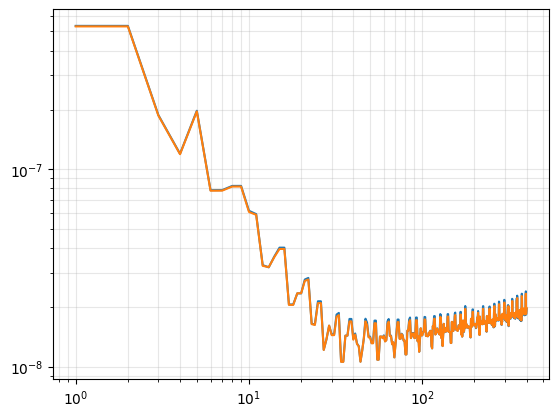

In [ ]:
D = 8.4
mag = 9.5
fs = 1000
n_subaps = int(np.sum(pyr_masks)/4)

slopes_cov = compute_slope_noise_variance(sn_ri=sn_ri, D=D, mag=mag, fs=fs, slopes_from_intensity=False, RON=10)
metaint_cov = compute_slope_noise_variance(sn_ri=sn_ri, D=D, mag=mag, fs=fs, slopes_from_intensity=True, RON=10)


# plt.figure()
# plt.loglog(slopes_cov)
# plt.loglog(metaint_cov)
# plt.grid(which='both',alpha=0.3)

plt.figure()
plt.loglog(x,np.diag(rec @ np.diag(slopes_cov) @ rec.T))
plt.loglog(x,np.diag(rec_ri @ np.diag(metaint_cov) @ rec_ri.T))
plt.grid(which='both',alpha=0.3)

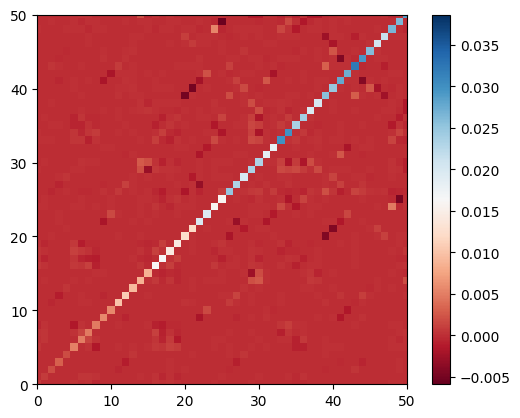

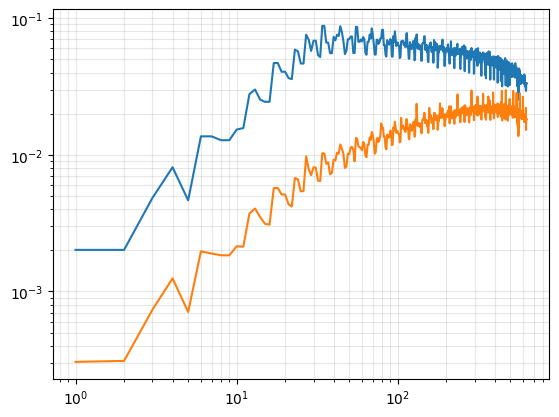

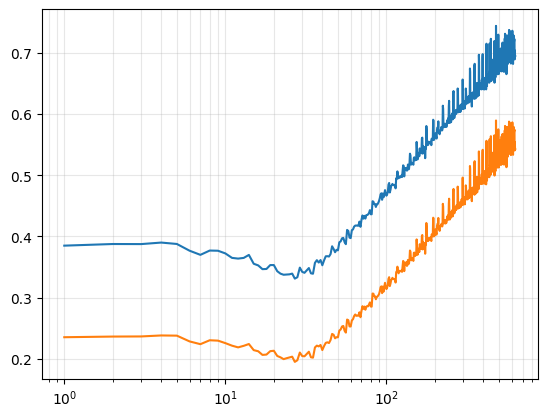

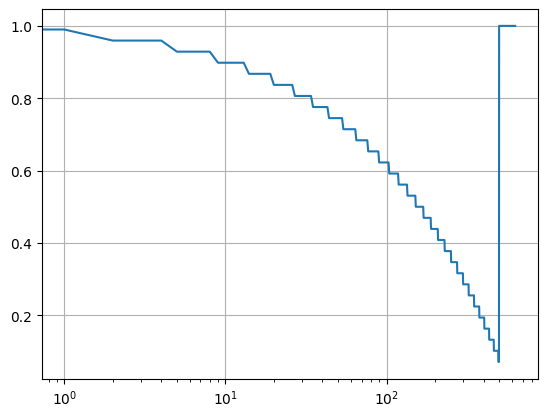

In [ ]:
def compute_optical_gain(IM, IMpc):
    norm = np.diag(IM.T @ IM)
    return np.diag(IMpc.T @ IM)/norm

im_pc = fits.getdata(os.path.join(root_dir, 'im/pyr3.0_s1.0_c0.9_im.fits'))
im_pc2 = fits.getdata(os.path.join(root_dir, 'im/pyr3.0_s1.4_c0.9_im.fits'))
cvec = fits.getdata(os.path.join(root_dir, 'data/correction_vector_500modes_c0.99.fits'))

ogs = compute_optical_gain(im, im_pc)
ogs2 = compute_optical_gain(im, im_pc2)
norm = np.diag(im.T @ im)
norm_pc = np.diag(im_pc.T @ im_pc)

plt.figure()
plt.imshow(im_pc.T @ im,cmap='RdBu')
plt.colorbar()
plt.xlim([0,50])
plt.ylim([0,50])

plt.figure()
plt.plot(np.arange(len(ogs))+1,norm)
plt.plot(np.arange(len(ogs))+1,norm_pc)
plt.xscale('log')
plt.yscale('log')
plt.grid(which='both',alpha=0.3)


plt.figure()
plt.plot(np.arange(len(ogs))+1,ogs)
plt.plot(np.arange(len(ogs))+1,ogs2)
plt.xscale('log')
plt.grid(which='both',alpha=0.3)

plt.figure()
plt.plot(cvec)
plt.xscale('log')
plt.grid()